In [229]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap


In [230]:
#reading in CSV and assigning it to a variable
df=pd.read_csv(r'signal_metrics_with_sigQUAL.csv')

In [231]:
# =========================
# 1. Column name constants
# =========================

LONGITUDE = "Longitude"
LATITUDE = "Latitude"
NETWORK = "Network Type"
SIGNAL = "Signal Strength (dBm)"
SIGNAL_QUALITY = "Signal Quality (%)"
THROUGHPUT = "Data Throughput (Mbps)"
LATENCY = "Latency (ms)"
BB60C = "BB60C Measurement (dBm)"
SRSRAN = "srsRAN Measurement (dBm)"
BLADERF = "BladeRFxA9 Measurement (dBm)"

ORDER = ["3G", "4G", "5G"]
#ORDER = ["5G"]

PALETTE = {
    "3G": "lightgreen",
    "4G": "skyblue",
    "LTE": "red",
    "5G": "lightcoral"
}

METRICS = [
    SIGNAL,
    SIGNAL_QUALITY,
    THROUGHPUT,
    LATENCY,
    BB60C,
    SRSRAN,
    BLADERF
]


In [232]:
# =========================
# 2. Filter dataframe once
# =========================

#df_4g5g = df.loc[df[NETWORK].isin(ORDER)].copy()



In [233]:

# =========================
# 3. Compute statistics
# =========================

def compute_boxplot_stats(data, group_col, metrics):
    stats = {}

    for metric in metrics:
        metric_stats = (
            data.groupby(group_col)[metric]
            .agg(
                Q1=lambda x: x.quantile(0.25),
                Median="median",
                Q3=lambda x: x.quantile(0.75)
            )

        )

        #print(metric)
        #print(metric_stats)
        metric_stats["IQR"] = metric_stats["Q3"] - metric_stats["Q1"]
        stats[metric] = metric_stats

    return stats


boxplot_stats = compute_boxplot_stats(
    data=df,
    group_col=NETWORK,
    metrics=METRICS
)
#print(boxplot_stats)

In [234]:

# =========================
# 4. Label function
# =========================

def label_boxplot_statistics(ax, stats, order):
    for i, category in enumerate(order):
        q1 = stats.loc[category, "Q1"]
        median = stats.loc[category, "Median"]
        q3 = stats.loc[category, "Q3"]
        iqr = stats.loc[category, "IQR"]

        ax.text(i + 0.12, q1, f"Q1 = {q1:.1f}", fontsize=9, va="center")

        ax.text(
            i + 0.12,
            median,
            f"Median = {median:.1f}",
            fontsize=9,
            fontweight="bold",
            va="center"
        )

        ax.text(i + 0.12, q3, f"Q3 = {q3:.1f}", fontsize=9, va="center")

        ax.text(
            i - 0.32,
            (q1 + q3) / 2,
            f"IQR = {iqr:.1f}",
            fontsize=9,
            bbox=dict(facecolor="white", alpha=0.7, edgecolor="none")
        )



In [235]:

# =========================
# 5. Reusable plot function
# =========================

def plot_metric_boxplot(data, metric, stats_dict):
    plt.figure(figsize=(8, 6))

    ax = sns.boxplot(
        data=data,
        x=NETWORK,
        y=metric,
        order=ORDER,
        palette=PALETTE,
        hue= NETWORK,
        legend=False
    )

    label_boxplot_statistics(
        ax=ax,
        stats=stats_dict[metric],
        order=ORDER
    )

    plt.title(f"{metric} Distribution")
    plt.xlabel("Network Type")
    plt.ylabel(metric)
    plt.grid(axis="y", linestyle="--", alpha=0.5)
    plt.tight_layout()
    plt.show()


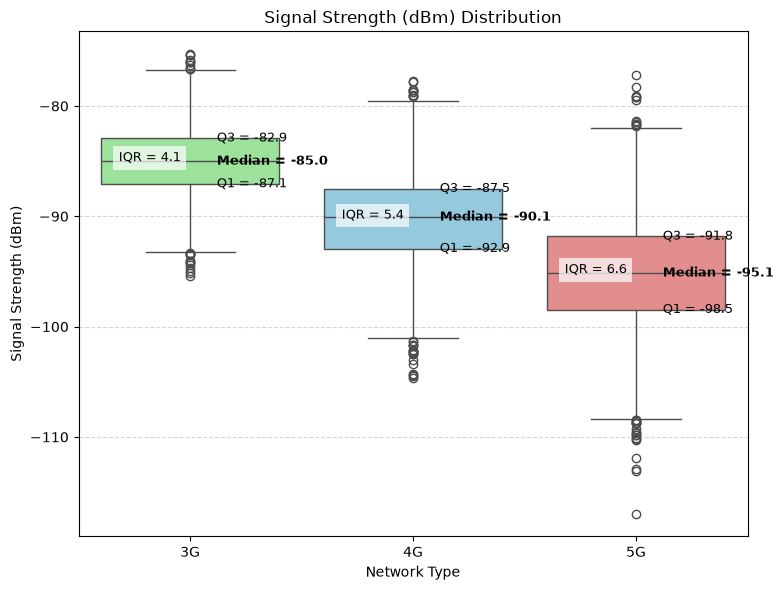

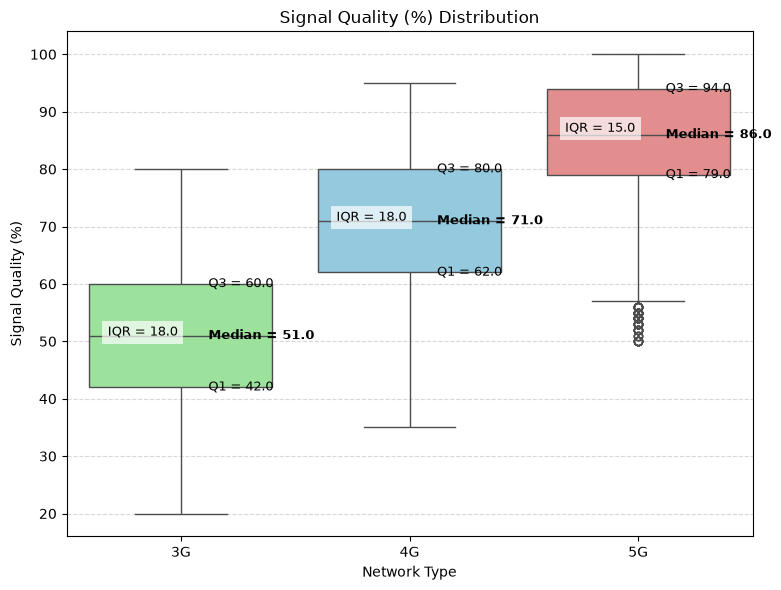

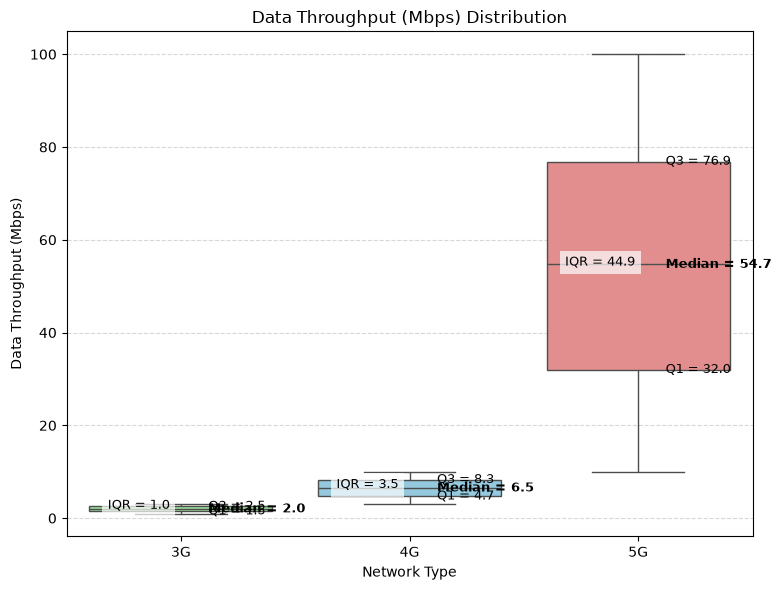

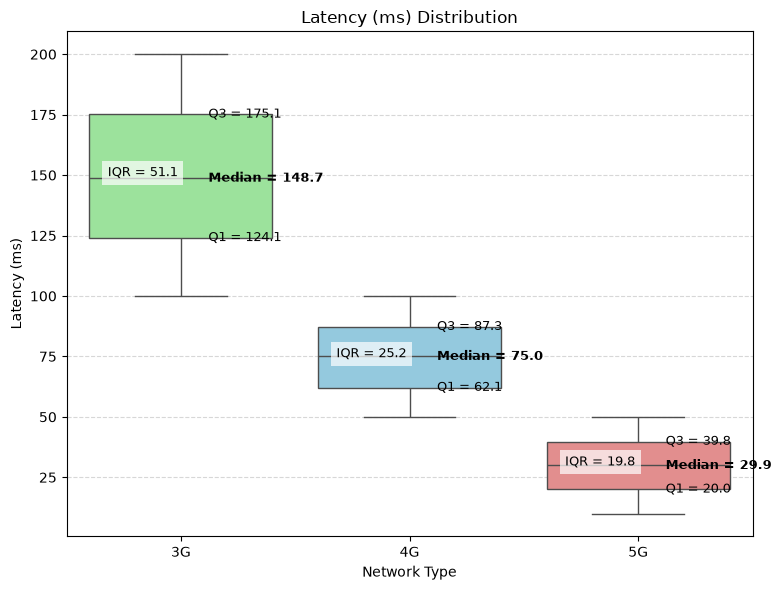

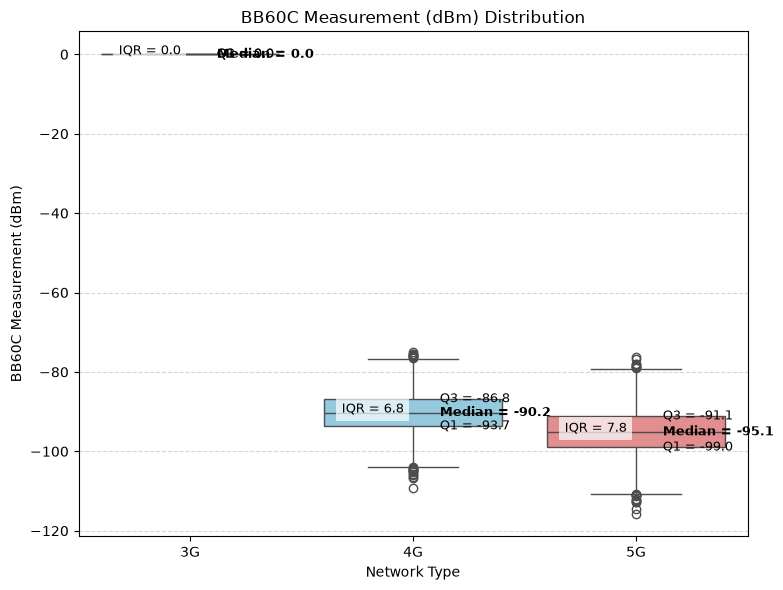

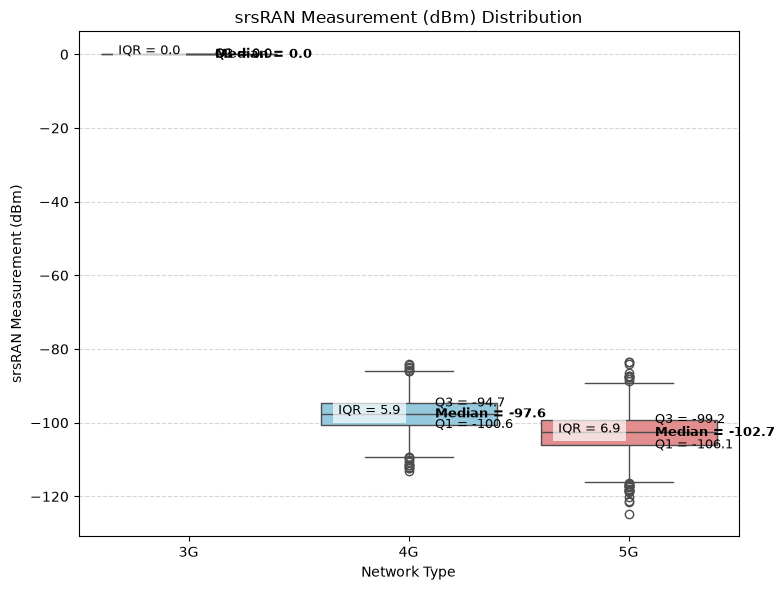

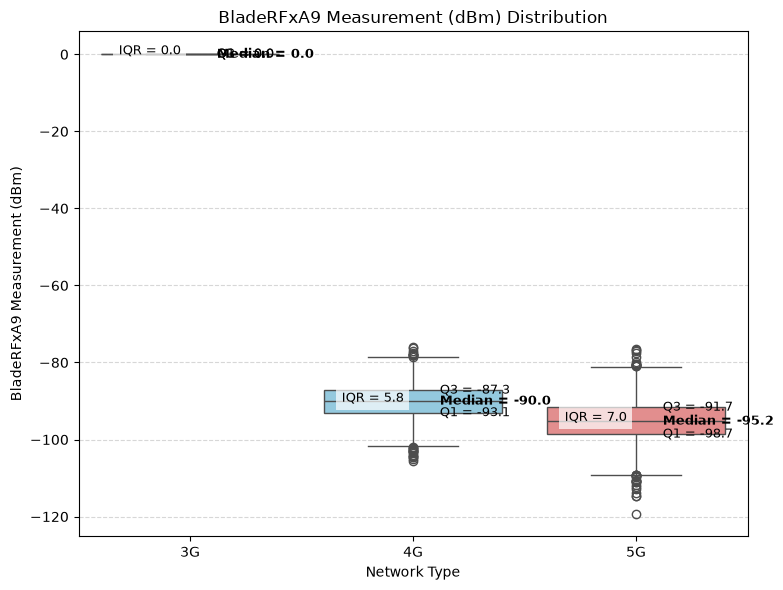

In [236]:
# =========================
# 6. Generate all boxplots
# =========================

for metric in METRICS:
    plot_metric_boxplot(
        data=df,
        metric=metric,
        stats_dict=boxplot_stats
    )

DEFINITION FOR METRIC HEATMAPS

In [237]:
# =========================
# 7. Reusable heatmap function
# =========================

def plot_heatmap(x, y, metric):

    for netType in ORDER:
        # df_netType = df[df[NETWORK] == netType]
        columns_to_extract = [LONGITUDE, LATITUDE, metric]
        df_netType = df.loc[df[NETWORK] == netType, columns_to_extract].copy() #uses less memory


        color = "RdYlGn"
        if metric == LATENCY: color = "RdYlGn_r"

        plt.figure(figsize=(8, 6))
        scatter = plt.scatter(
            x = df_netType[LONGITUDE],
            y = df_netType[LATITUDE],
            s=80,
            c = df_netType[metric],
            cmap = color,
            edgecolor="black",
            linewidth=0.4
        )

        cbar = plt.colorbar(scatter)
        cbar.set_label(metric)

        plt.title(f"{netType} {metric}")
        plt.xlabel("Longitude")
        plt.ylabel("Latitude")

        plt.grid(True, linestyle="--", alpha=0.4)
        plt.tight_layout()
        plt.show()

In [238]:
# =========================
# 8. Reusable NORMALIZED heatmap function
# =========================

def plot_normalized_heatmap(x, y, metric):

    for netType in ORDER:
        columns_to_extract = [LONGITUDE, LATITUDE, metric]
        df_netType_norm = df.loc[df[NETWORK] == netType, columns_to_extract].copy()
        df_netType_norm["Normalized"] = (df_netType_norm[metric] - df_netType_norm[metric].min()) / (df_netType_norm[metric].max() - df_netType_norm[metric].min())
        #print(df_netType_norm.head())
        # df_all_norms = df_netType_norm.join(df_netType_norm["Normalized"], how='right')
        # print(df_all_norms.head())

        color = "RdYlGn"
        if metric == LATENCY: color = "RdYlGn_r"

        plt.figure(figsize=(8, 6))
        scatter = plt.scatter(
            x = df_netType_norm[LONGITUDE],
            y = df_netType_norm[LATITUDE],
            s=80,
            c = df_netType_norm["Normalized"],
            cmap = color,
            edgecolor="black",
            linewidth=0.4
        )

        cbar = plt.colorbar(scatter)
        cbar.set_label(metric)

        plt.title(f"{netType} Normalized {metric}")
        plt.xlabel("Longitude")
        plt.ylabel("Latitude")

        plt.grid(True, linestyle="--", alpha=0.4)
        plt.tight_layout()
        plt.show()

    #return df_netType_norm

START OF METRIC HEATMAPS

In [239]:
# =========================
# 9. heatmap functions
# =========================
# for metric in METRICS:
#     plot_heatmap(
#         x = df[LONGITUDE],
#         y = df[LATITUDE],
#         metric = metric
#     )

#     plot_normalized_heatmap(
#         x = df[LONGITUDE],
#         y = df[LATITUDE],
#         metric = metric
#     )

START OF QOE ANALYSIS

In [240]:
# =========================
# 10. making raw dataframe for Qality of Experience
# =========================

df_qoe = df[df[NETWORK].isin(ORDER)].copy()

In [241]:
# =========================
# 11. normalizing data for Qality of Experience
# =========================

def minmax_normalize(series, higher_is_better=True):
    """
    Normalize a pandas Series to 0–1.
    If higher_is_better=False, lower raw values receive higher normalized scores.
    """
    series = pd.to_numeric(series, errors="coerce")

    min_val = series.min()
    max_val = series.max()

    if max_val == min_val:
        return pd.Series(1.0, index=series.index)

    normalized = (series - min_val) / (max_val - min_val)

    if not higher_is_better:
        normalized = 1 - normalized

    return normalized

In [242]:
# Normalize KPIs
df_qoe["norm_signal"] = minmax_normalize(
    df_qoe[SIGNAL],
    higher_is_better=True
)

df_qoe["norm_signal_quality"] = minmax_normalize(
    df_qoe[SIGNAL_QUALITY],
    higher_is_better=True
)

df_qoe["norm_throughput"] = minmax_normalize(
    df_qoe[THROUGHPUT],
    higher_is_better=True
)

df_qoe["norm_latency"] = minmax_normalize(
    df_qoe[LATENCY],
    higher_is_better=False
)

# Radio Quality Index
df_qoe["RQI"] = (
    0.6 * df_qoe["norm_signal_quality"] +
    0.4 * df_qoe["norm_signal"]
)

# Service Performance Index
df_qoe["SPI"] = (
    0.6 * df_qoe["norm_throughput"] +
    0.4 * df_qoe["norm_latency"]
)

# Overall QoE Score
df_qoe["QoE"] = (
    0.6 * df_qoe["SPI"] +
    0.4 * df_qoe["RQI"]
)

# Optional: convert to 0–100 scale
QOE_PERCENT = "QoE_percent"
QOE_RATING = "QoE_rating"

df_qoe[QOE_PERCENT] = df_qoe["QoE"] * 100

#df_qoe

QOE CLASSIFIED INTO POOR TO EXCELLENT

In [243]:
# classify QoE
def classify_qoe(score):
    if score >= 90:
        return "Excellent"
    elif score >= 80:
        return "Very Good"
    elif score >= 70:
        return "Good"
    elif score >= 60:
        return "Fair"
    else:
        return "Poor"


df_qoe["QoE_rating"] = df_qoe["QoE_percent"].apply(classify_qoe)

# Preview result
df_qoe.head()

,Timestamp,Locality,Latitude,Longitude,Signal Strength (dBm),Signal Quality (%),Data Throughput (Mbps),Latency (ms),Network Type,BB60C Measurement (dBm),...,BladeRFxA9 Measurement (dBm),norm_signal,norm_signal_quality,norm_throughput,norm_latency,RQI,SPI,QoE,QoE_percent,QoE_rating
0,50:40.0,Anisabad,25.599109,85.137355,-84.274113,47,1.863890,129.122914,3G,0.0,...,0.0,0.784769,0.3375,0.008723,0.372982,0.516408,0.154427,0.299219,29.921896,Poor
1,18:44.9,Boring Road,25.564499,85.088607,-84.643065,58,1.567842,130.536386,3G,0.0,...,0.0,0.775906,0.4750,0.005732,0.365540,0.595362,0.149656,0.327938,32.793827,Poor
2,34:20.9,Rajendra Nagar,25.698981,85.193941,-79.656127,45,1.116387,191.521373,3G,0.0,...,0.0,0.895704,0.3125,0.001172,0.044486,0.545782,0.018497,0.229411,22.941099,Poor
3,40:35.4,Gandhi Maidan,25.470778,85.106450,-85.607373,47,2.171551,194.023024,3G,0.0,...,0.0,0.752741,0.3375,0.011831,0.031316,0.503596,0.019625,0.213214,21.321358,Poor
4,05:33.0,Kumhrar,25.573279,85.158042,-83.978154,44,1.753478,174.957830,3G,0.0,...,0.0,0.791879,0.3000,0.007608,0.131684,0.496751,0.057238,0.233044,23.304357,Poor


In [244]:
# # classify Signal Strength
# def classify_signal_str(score):
#     if score >= 90:
#         return "Excellent"
#     elif score >= 80:
#         return "Very Good"
#     elif score >= 70:
#         return "Good"
#     elif score >= 60:
#         return "Fair"
#     else:
#         return "Poor"


# df_qoe["QoE_rating"] = df_qoe["QoE_percent"].apply(classify_qoe)


DISTRIBUTION QOE PLOTS

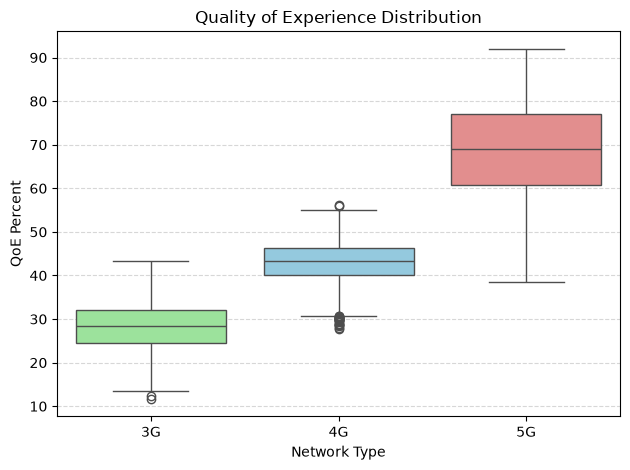

In [245]:
# Distribution of QoE by Network Type
ax = sns.boxplot(
    data = df_qoe,
    x = df[NETWORK],
    y = QOE_PERCENT,
    hue = df[NETWORK],
    order = ORDER,
    palette= PALETTE,
    legend=False,
)

# QOE_METRICS = [QOE_PERCENT]

# boxplot_stats = compute_boxplot_stats(
#     data=df_qoe,
#     group_col=NETWORK,
#     metrics= QOE_METRICS
# )

plt.title(f"Quality of Experience Distribution")
plt.xlabel("Network Type")
plt.ylabel("QoE Percent")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()


START OF QOE HEATMAPS

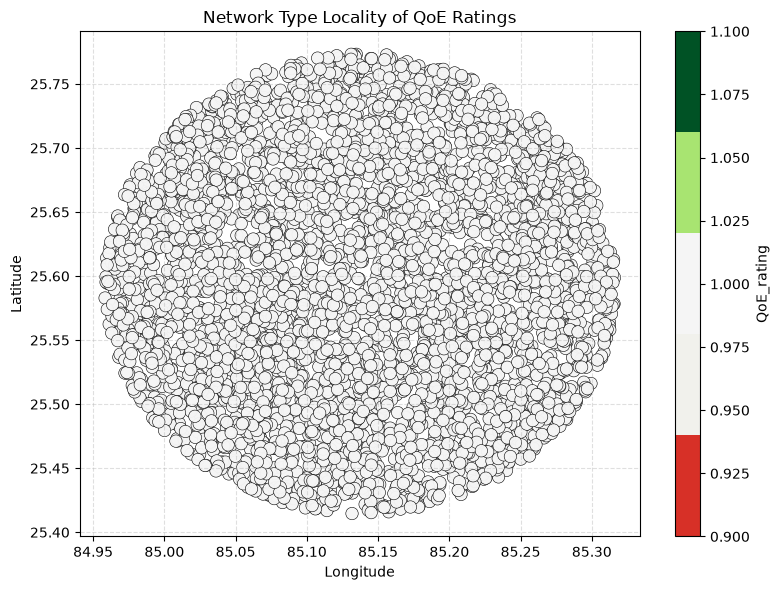

In [275]:
# Map QoE ratings to numerical values

qoe_map = {
    "Poor": 1,
    "Fair": 2,
    "Good": 3,
    "Very Good": 4,
    "Excellent": 5
}

# # Custom Ericsson-style color progression
# cmap = ListedColormap([
#     "#d73027",   # Poor - Red
#     "#fc8d59",   # Fair - Orange
#     "#fee08b",   # Good - Yellow
#     "#91cf60",   # Very Good - Light Green
#     "#1a9850"    # Excellent - Green
# ])

cmap = ListedColormap([
    "#d73027",   # Poor - Red
    "#f1f1ec",   # Fair - Orange
    "#f5f5f5f9",   # Good - Yellow
    "#a8e471",   # Very Good - Light Green
    "#005225"    # Excellent - Green
])

 # Convert to a single-column matrix
columns_to_extract = [LONGITUDE, LATITUDE, QOE_RATING]
df_qoe_3G = df_qoe.loc[df_qoe[NETWORK] == "4G", columns_to_extract].copy() #uses less memory

df_qoe_3G["QoE_numeric"] = df_qoe_3G[QOE_RATING].map(qoe_map)

# 3G Heatmap for QoE
heatmap_data = df_qoe_3G[["QoE_numeric"]]

plt.figure(figsize=(8, 6))
scatter = plt.scatter(
    x = df_qoe_3G[LONGITUDE],
    y = df_qoe_3G[LATITUDE],
    s=80,
    c = heatmap_data["QoE_numeric"],
    cmap = cmap,
    edgecolor="black",
    linewidth=0.4
)

cbar = plt.colorbar(scatter)
cbar.set_label(QOE_RATING)

plt.title(f"{NETWORK} Locality of QoE Ratings")
plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

In [267]:
df_qoe.head()

,Timestamp,Locality,Latitude,Longitude,Signal Strength (dBm),Signal Quality (%),Data Throughput (Mbps),Latency (ms),Network Type,BB60C Measurement (dBm),...,BladeRFxA9 Measurement (dBm),norm_signal,norm_signal_quality,norm_throughput,norm_latency,RQI,SPI,QoE,QoE_percent,QoE_rating
0,50:40.0,Anisabad,25.599109,85.137355,-84.274113,47,1.863890,129.122914,3G,0.0,...,0.0,0.784769,0.3375,0.008723,0.372982,0.516408,0.154427,0.299219,29.921896,Poor
1,18:44.9,Boring Road,25.564499,85.088607,-84.643065,58,1.567842,130.536386,3G,0.0,...,0.0,0.775906,0.4750,0.005732,0.365540,0.595362,0.149656,0.327938,32.793827,Poor
2,34:20.9,Rajendra Nagar,25.698981,85.193941,-79.656127,45,1.116387,191.521373,3G,0.0,...,0.0,0.895704,0.3125,0.001172,0.044486,0.545782,0.018497,0.229411,22.941099,Poor
3,40:35.4,Gandhi Maidan,25.470778,85.106450,-85.607373,47,2.171551,194.023024,3G,0.0,...,0.0,0.752741,0.3375,0.011831,0.031316,0.503596,0.019625,0.213214,21.321358,Poor
4,05:33.0,Kumhrar,25.573279,85.158042,-83.978154,44,1.753478,174.957830,3G,0.0,...,0.0,0.791879,0.3000,0.007608,0.131684,0.496751,0.057238,0.233044,23.304357,Poor


In [268]:
df_qoe_3G["QoE_numeric"].value_counts()

QoE_numeric
3    1291
2    1228
1     964
4     682
5      13
Name: count, dtype: int64